In [3]:
%%duckdb
CREATE OR REPLACE TABLE hn_veri AS 
SELECT * FROM 's3://bauntek-bootcamp-shared/hackernews.parquet';

,Count
0,876006


In [4]:
%%duckdb
SELECT *
FROM hn_veri
WHERE type IN ('story', 'comment', 'job', 'poll', 'pollopt');

,id,deleted,type,by,time,text,dead,parent,poll,kids,url,score,title,parts,descendants
0,21921793,False,comment,chaosite,2019-12-31 15:50:12,Gawker?,False,21921747,<NA>,[],None,0,None,[],0
1,21921794,False,comment,ghaff,2019-12-31 15:50:20,"If you haven&#x27;t done so, you might check i...",False,21921334,<NA>,[21922803],None,0,None,[],0
2,21921795,False,story,p0llard,2019-12-31 15:50:22,None,False,<NA>,<NA>,"[21922471, 21924093]",http://adam.chlipala.net/frap/frap_book.pdf,83,Formal Reasoning About Programs (2017) [pdf],[],23
3,21921796,False,comment,maxmindjason,2019-12-31 15:50:26,Yes. We will add them back if we are confident...,False,21916767,<NA>,[],None,0,None,[],0
4,21921797,False,comment,brudgers,2019-12-31 15:50:26,"dupe a few months ago, <a href=""https:&#x2F;&#...",False,21919769,<NA>,[],None,0,None,[],0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876001,4042955,False,comment,bceagle,2012-05-30 14:31:09,Yeah...this depresses me. I am one of those gu...,False,4042741,<NA>,[4043076],None,0,None,[],0
876002,4042956,False,story,cloudpre,2012-05-30 14:31:10,There are lots of full-blown help desk tools w...,True,<NA>,<NA>,[],None,1,Show HN: Why did we launch a free help desk?,[],-1
876003,4042957,False,story,evo_9,2012-05-30 14:31:16,None,False,<NA>,<NA>,[4044074],http://arstechnica.com/business/2012/05/not-ju...,28,Not just the browser: why buying Opera makes s...,[],3
876004,4042958,True,comment,None,2012-05-30 14:31:16,None,False,4042796,<NA>,[],None,0,None,[],0


In [5]:
import duckdb

anomali_1970 = duckdb.table("hn_veri").filter("year(time) < 2006").df()
anomali_eksi_yorum = duckdb.table("hn_veri").filter("descendants == -1").df()

print("Unix Epoch Hatası")
display(anomali_1970[['id', 'title', 'time', 'type']])

print("\nSistem Hatasından Ötürü Yorum Sayısı (-1) Düşmüş Olan Kayıtlar")
display(anomali_eksi_yorum[['id', 'dead','title', 'descendants', 'type']])

Unix Epoch Hatası


,id,title,time,type
0,344075,None,1970-01-01,story
1,344126,None,1970-01-01,story
2,344140,None,1970-01-01,story
3,344158,None,1970-01-01,story
4,344196,None,1970-01-01,story
...,...,...,...,...
1254,4045659,None,1970-01-01,story
1255,4045671,None,1970-01-01,story
1256,4045677,None,1970-01-01,story
1257,4045683,None,1970-01-01,story



Sistem Hatasından Ötürü Yorum Sayısı (-1) Düşmüş Olan Kayıtlar


,id,dead,title,descendants,type
0,344071,True,Free Samples : Free Stuff : Freebies,-1,story
1,344073,True,Great Source for Astrology,-1,story
2,344136,True,Stop Home Foreclosure,-1,story
3,344145,True,Wedding Snafu,-1,story
4,344153,True,Free Coloring Pages The Cheetah Girls,-1,story
...,...,...,...,...,...
10915,4046823,True,刷票公司,-1,story
10916,4046836,True,Keyboard shortcuts in Windows Explorer in Wind...,-1,story
10917,4046844,True,Preface,-1,story
10918,4046845,True,ZTE Athena Is Now The World Thinnest Smartphone,-1,story


In [3]:
%%duckdb
DESCRIBE hn_veri;

,column_name,column_type,null,key,default,extra
0,id,BIGINT,YES,None,None,None
1,deleted,BOOLEAN,YES,None,None,None
2,type,VARCHAR,YES,None,None,None
3,by,VARCHAR,YES,None,None,None
4,time,TIMESTAMP,YES,None,None,None
5,text,VARCHAR,YES,None,None,None
6,dead,BOOLEAN,YES,None,None,None
7,parent,BIGINT,YES,None,None,None
8,poll,BIGINT,YES,None,None,None
9,kids,BIGINT[],YES,None,None,None


In [6]:
%%duckdb
SELECT 
    count(*)                                    AS toplam_satir,
    count(DISTINCT type)                        AS farkli_tip_sayisi,
    count(*) FILTER (WHERE type = 'story')      AS story,
    count(*) FILTER (WHERE type = 'comment')    AS comment,
    count(*) FILTER (WHERE type = 'job')        AS job,
    count(*) FILTER (WHERE type = 'poll')       AS poll,
    count(*) FILTER (WHERE type = 'pollopt')    AS pollopt,
    min(year(time))                             AS en_eski_yil,
    max(year(time))                             AS en_yeni_yil
FROM hn_veri;

,toplam_satir,farkli_tip_sayisi,story,comment,job,poll,pollopt,en_eski_yil,en_yeni_yil
0,876006,5,153947,721397,453,34,175,1970,2020


In [11]:
%%duckdb
SELECT 
    'Ham veri (başlangic)'              AS asama,
    count(*)                            AS kalan_satir,
    0                                   AS bu_adimda_silinen,
    'Başlangıç noktası'                 AS aciklama
FROM hn_veri

UNION ALL

SELECT 
    '1. Sadece story tipi',
    count(*),
    (SELECT count(*) FROM hn_veri) - count(*),
    'comment/job/poll/pollopt çıkarıldı'
FROM hn_veri
WHERE type = 'story'

UNION ALL

SELECT 
    '2. Anomali: 1970 tarihleri',
    count(*),
    (SELECT count(*) FROM hn_veri WHERE type = 'story') - count(*),
    'year(time)<2006 → Unix epoch sıfırı'
FROM hn_veri
WHERE type = 'story'
  AND year(time) >= 2006 AND year(time) <= 2025

UNION ALL

SELECT 
    '3. Anomali: dead + deleted',
    count(*),
    (SELECT count(*) FROM hn_veri 
     WHERE type='story' AND year(time)>=2006 AND year(time)<=2025) - count(*),
    'dead=true veya deleted=true olan içerikler'
FROM hn_veri
WHERE type = 'story'
  AND year(time) >= 2006 AND year(time) <= 2025
  AND (dead    IS NULL OR dead    = false)
  AND (deleted IS NULL OR deleted = false)

UNION ALL

SELECT 
    '4. Anomali: descendants = -1',
    count(*),
    (SELECT count(*) FROM hn_veri 
     WHERE type='story' AND year(time)>=2006 AND year(time)<=2025
       AND (dead IS NULL OR dead=false) 
       AND (deleted IS NULL OR deleted=false)) - count(*),
    'dead/deleted kalıntısı → -1 yorum sayısı'
FROM hn_veri
WHERE type = 'story'
  AND title IS NOT NULL AND title != ''
  AND year(time) >= 2006 AND year(time) <= 2025
  AND (dead    IS NULL OR dead    = false)
  AND (deleted IS NULL OR deleted = false)
  AND descendants != -1

ORDER BY kalan_satir DESC;

,asama,kalan_satir,bu_adimda_silinen,aciklama
0,Ham veri (başlangic),876006,0,Başlangıç noktası
1,1. Sadece story tipi,153947,722059,comment/job/poll/pollopt çıkarıldı
2,2. Anomali: 1970 tarihleri,152688,1259,year(time)<2006 → Unix epoch sıfırı
3,3. Anomali: dead + deleted,120463,32225,dead=true veya deleted=true olan içerikler
4,4. Anomali: descendants = -1,120463,0,dead/deleted kalıntısı → -1 yorum sayısı


In [13]:
%%duckdb
CREATE OR REPLACE TABLE hn_temiz AS
SELECT *, EXTRACT(YEAR FROM time) AS yil
FROM hn_veri
WHERE type = 'story'
  AND EXTRACT(YEAR FROM time) >= 2006 AND EXTRACT(YEAR FROM time) <= 2025
  AND (dead IS NULL OR dead = false)
  AND (deleted IS NULL OR deleted = false)
  AND descendants != -1
  AND title IS NOT NULL AND title != '';

,Count
0,120463


In [14]:
%%duckdb
CREATE OR REPLACE TABLE panik_analiz AS
SELECT 
    yil,
    count(*) AS toplam_story,

    -- Korku kelimeleri (hepsi regexp ile tam kelime)
    count(*) FILTER (WHERE regexp_matches(title, '\b(is dead|has died)\b', 'i'))                        AS olum,
    count(*) FILTER (WHERE regexp_matches(title, '\b(bubble|overhyped)\b', 'i'))                        AS balon,
    count(*) FILTER (WHERE regexp_matches(title, '\b(will replace|replacing|end of)\b', 'i'))           AS yerini_alacak,
    count(*) FILTER (WHERE regexp_matches(title, '\bfail(s|ed|ing|ure)?\b', 'i')
                        OR regexp_matches(title, '\b(collapse|dying)\b', 'i'))                          AS cokus,

    -- Umut kelimeleri
    count(*) FILTER (WHERE regexp_matches(title, '\b(is back|comeback)\b', 'i'))                        AS dirilis,
    count(*) FILTER (WHERE regexp_matches(title, '\b(future of|revolution|breakthrough)\b', 'i'))       AS umut,

    -- Teknoloji hacimleri (tam kelime)
    count(*) FILTER (WHERE regexp_matches(title, '(\s|^)(AI|LLM|GPT-?[0-9]?)(\s|$|[,\.!?:])', 'i')
                        OR regexp_matches(title, '\b(artificial intelligence|machine learning|deep learning)\b', 'i')) AS ai_adet,
    count(*) FILTER (WHERE regexp_matches(title, '\b(blockchain|bitcoin|crypto|ethereum|NFT|web3)\b', 'i'))            AS kripto_adet,
    count(*) FILTER (WHERE regexp_matches(title, '\b(cloud|serverless|kubernetes)\b', 'i')
                        OR regexp_matches(title, '(\s|^)(AWS|GCP|Azure)(\s|$|[,\.!?:])', 'i'))                        AS cloud_adet,


    round(avg(score), 2)                                                AS ort_puan,
    round(avg(descendants) FILTER (WHERE descendants >= 0), 2)         AS ort_yorum

FROM hn_temiz
GROUP BY yil
ORDER BY yil;

SELECT * FROM panik_analiz;

,yil,toplam_story,olum,balon,yerini_alacak,cokus,dirilis,umut,ai_adet,kripto_adet,cloud_adet,ort_puan,ort_yorum
0,2006,45,1,1,0,0,0,0,0,0,0,6.31,0.44
1,2007,21663,21,68,37,145,10,125,39,0,25,5.23,3.21
2,2008,17004,9,11,36,118,8,75,23,2,131,7.28,4.01
3,2009,6464,5,6,13,54,7,39,5,0,46,8.63,5.02
4,2012,15401,16,24,13,80,4,70,16,21,158,11.96,5.08
5,2014,13689,6,17,21,78,11,61,39,157,140,14.00,6.26
6,2016,13436,19,9,17,68,7,72,166,182,172,15.13,6.27
7,2017,11504,16,12,21,51,14,56,342,264,232,16.21,7.54
8,2018,11128,15,3,15,58,5,63,318,207,221,18.17,8.59
9,2019,2657,1,4,8,18,0,9,45,29,29,19.26,8.55


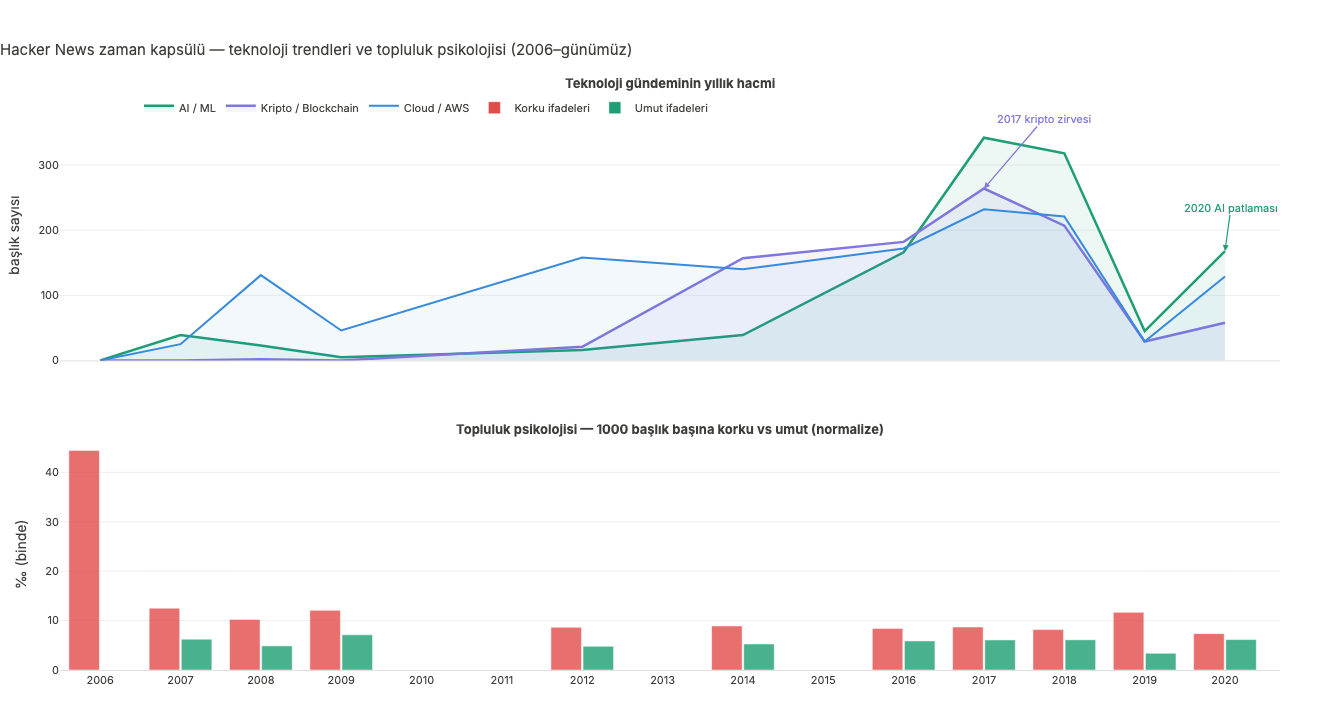

In [15]:
import duckdb
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df = duckdb.query("SELECT * FROM panik_analiz ORDER BY yil").df()

df['panik_toplam'] = df['olum'] + df['balon'] + df['yerini_alacak'] + df['cokus']
df['umut_toplam']  = df['dirilis'] + df['umut']
df['panik_norm']   = (df['panik_toplam'] / df['toplam_story']) * 1000
df['umut_norm']    = (df['umut_toplam']  / df['toplam_story']) * 1000

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    row_heights=[0.52, 0.48],
    vertical_spacing=0.14,
    subplot_titles=[
        "Teknoloji gündeminin yıllık hacmi",
        "Topluluk psikolojisi — 1000 başlık başına korku vs umut (normalize)"
    ]
)

fig.add_trace(go.Scatter(
    x=df['yil'], y=df['ai_adet'],
    name='AI / ML', mode='lines',
    line=dict(color='#1D9E75', width=2.5),
    fill='tozeroy', fillcolor='rgba(29,158,117,0.08)'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df['yil'], y=df['kripto_adet'],
    name='Kripto / Blockchain', mode='lines',
    line=dict(color='#7F77DD', width=2.5),
    fill='tozeroy', fillcolor='rgba(127,119,221,0.08)'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df['yil'], y=df['cloud_adet'],
    name='Cloud / AWS', mode='lines',
    line=dict(color='#378ADD', width=2),
    fill='tozeroy', fillcolor='rgba(55,138,221,0.06)'
), row=1, col=1)

fig.add_annotation(
    x=2017,
    y=df.loc[df['yil']==2017, 'kripto_adet'].values[0],
    text="2017 kripto zirvesi",
    showarrow=True, arrowhead=2, arrowwidth=1.2,
    arrowcolor='#7F77DD', ax=60, ay=-70,
    font=dict(size=11, color='#7F77DD'),
    bgcolor='rgba(0,0,0,0)', bordercolor='rgba(0,0,0,0)',
    row=1, col=1
)
fig.add_annotation(
    x=2020,
    y=df.loc[df['yil']==2020, 'ai_adet'].values[0],
    text="2020 AI patlaması",
    showarrow=True, arrowhead=2, arrowwidth=1.2,
    arrowcolor='#1D9E75', ax=6, ay=-44,
    font=dict(size=11, color='#1D9E75'),
    bgcolor='rgba(0,0,0,0)', bordercolor='rgba(0,0,0,0)',
    row=1, col=1
)

# Alt grafik
fig.add_trace(go.Bar(
    x=df['yil'], y=df['panik_norm'],
    name='Korku ifadeleri',
    marker=dict(color='#E24B4A', opacity=0.8),
    width=0.38
), row=2, col=1)

fig.add_trace(go.Bar(
    x=df['yil'], y=df['umut_norm'],
    name='Umut ifadeleri',
    marker=dict(color='#1D9E75', opacity=0.8),
    width=0.38
), row=2, col=1)


FONT_COLOR  = '#3d3d3a'  
GRID_COLOR  = 'rgba(0,0,0,0.07)'
LINE_COLOR  = 'rgba(0,0,0,0.12)'

fig.update_layout(
    height=720,
    barmode='group',
    template='plotly_white',
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    font=dict(family='Inter, Arial, sans-serif', size=12, color=FONT_COLOR),
    title=dict(
        text="Hacker News zaman kapsülü — teknoloji trendleri ve topluluk psikolojisi (2006–günümüz)",
        font=dict(size=15, color=FONT_COLOR),
        x=0.0, xanchor='left'
    ),
    legend=dict(
        orientation='h', 
        y=1.03,     
        x=0.3,
        xanchor='center',
        font=dict(size=11, color='#444441'),
        bgcolor='rgba(0,0,0,0)',
        borderwidth=0
    ),
    margin=dict(l=60, r=40, t=110, b=50),
)


for ann in fig['layout']['annotations']:
    if ann['text'] in [
        "Teknoloji gündeminin yıllık hacmi",
        "Topluluk psikolojisi — 1000 başlık başına korku vs umut (normalize)"
    ]:
        ann['font'] = dict(size=13, color=FONT_COLOR, weight='bold')
        if ann['text'] == "Teknoloji gündeminin yıllık hacmi":
            ann['y'] = 1.03

fig.update_xaxes(
    showgrid=False,
    showline=True, linecolor=LINE_COLOR,
    tickfont=dict(size=11, color=FONT_COLOR),
    dtick=1
)
fig.update_yaxes(
    showgrid=True, gridcolor=GRID_COLOR,
    showline=False,
    tickfont=dict(size=11, color=FONT_COLOR),
    zeroline=False
)
fig.update_yaxes(title_text="başlık sayısı", title_font=dict(color=FONT_COLOR), row=1, col=1)
fig.update_yaxes(title_text="‰ (binde)",     title_font=dict(color=FONT_COLOR), row=2, col=1)

fig.show()

In [17]:
%%duckdb
CREATE OR REPLACE TABLE ml_hazir_veri AS
SELECT 
    title, 
    yil, 
    score,
    CASE 
        WHEN title ILIKE '%is dead%'      OR title ILIKE '%has died%'  
          OR title ILIKE '%bubble%'       OR title ILIKE '%overhyped%'  
          OR title ILIKE '%will replace%' OR title ILIKE '%end of%'  
          OR title ILIKE '%dying%'         OR title ILIKE '%collapse%'  
          OR title ILIKE '%doomed%'        OR title ILIKE '%failing%'  
        THEN 1 ELSE 0
    END AS panik_etiketi
FROM hn_temiz;

,Count
0,120463


L1 Regülasyonlu Model Başarım Raporu:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     23945
       Panik       0.21      0.82      0.33       148

    accuracy                           0.98     24093
   macro avg       0.60      0.90      0.66     24093
weighted avg       0.99      0.98      0.99     24093



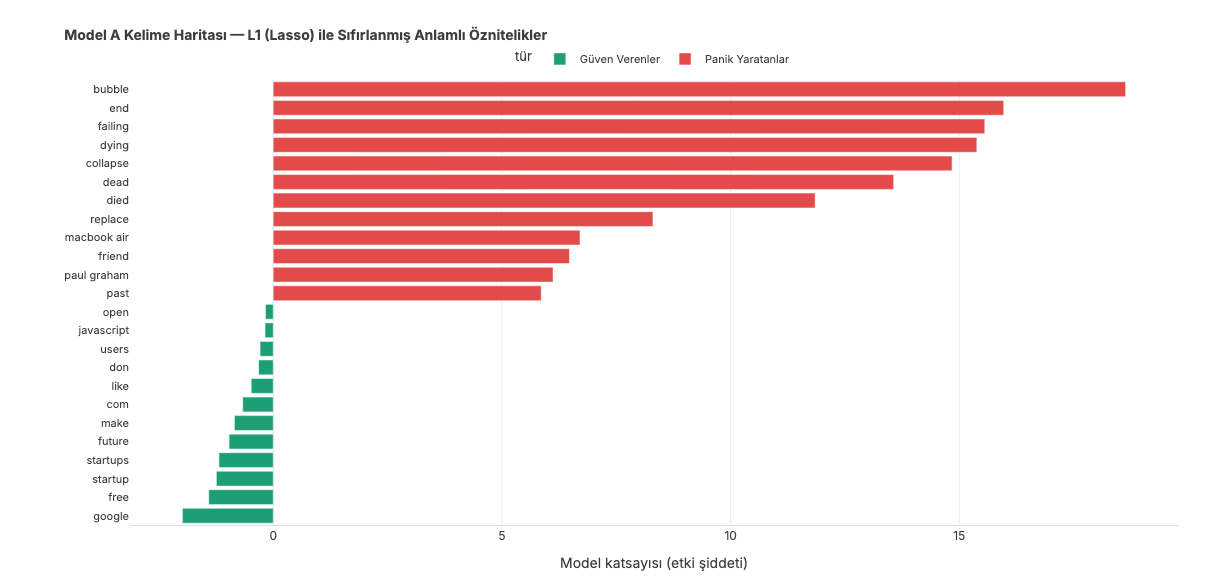

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import scipy.sparse as sp
import pandas as pd
import numpy as np
import duckdb
import plotly.express as px

df_ml = duckdb.query("SELECT * FROM ml_hazir_veri").df()



vectorizer = TfidfVectorizer(
    max_features=2500,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=25,       
    max_df=0.3,       
    token_pattern=r'[a-zA-Z]{3,}'
)

X_raw = vectorizer.fit_transform(df_ml['title'])
y_raw = df_ml['panik_etiketi'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

panik_idx  = np.where(y_train == 1)[0]
normal_idx = np.where(y_train == 0)[0]

n_samples = len(normal_idx)
chosen = np.random.RandomState(42).choice(panik_idx, size=n_samples, replace=True)

X_train_bal = sp.vstack([X_train[normal_idx], X_train[chosen]])
y_train_bal = np.concatenate([y_train[normal_idx], y_train[chosen]])


model_a = LogisticRegression(
    penalty='l1', 
    solver='liblinear', 
    C=0.05, 
    class_weight='balanced', 
    max_iter=1000, 
    random_state=42
)
model_a.fit(X_train_bal, y_train_bal)


print("L1 Regülasyonlu Model Başarım Raporu:")
print(classification_report(y_test, model_a.predict(X_test), target_names=['Normal', 'Panik']))


feature_names = vectorizer.get_feature_names_out()
coef = model_a.coef_[0]

coef_ham = pd.Series(coef, index=feature_names)

top_n      = 12
top_panik  = coef_ham.nlargest(top_n)
top_normal = coef_ham.nsmallest(top_n)


df_feat = pd.concat([
    pd.DataFrame({'kelime': top_panik.index,  'ağırlık': top_panik.values,  'tür': 'Panik Yaratanlar'}),
    pd.DataFrame({'kelime': top_normal.index, 'ağırlık': top_normal.values, 'tür': 'Güven Verenler'})
]).sort_values(by='ağırlık')

FONT_COLOR = '#3d3d3a'
GRID_COLOR = 'rgba(0,0,0,0.07)'
LINE_COLOR = 'rgba(0,0,0,0.12)'

fig3 = px.bar(
    df_feat, x='ağırlık', y='kelime', color='tür',
    orientation='h',
    color_discrete_map={'Panik Yaratanlar': '#E24B4A', 'Güven Verenler': '#1D9E75'},
    title='<b> Model A Kelime Haritası — L1 (Lasso) ile Sıfırlanmış Anlamlı Öznitelikler</b>',
    labels={'ağırlık': 'Model katsayısı (etki şiddeti)', 'kelime': ''},
    template='plotly_white',
    height=580
)

fig3.update_layout(
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    font=dict(family='Inter, Arial, sans-serif', size=12, color=FONT_COLOR),
    title=dict(font=dict(size=14, color=FONT_COLOR)),
    legend=dict(orientation='h', y=1.08, x=0.5, xanchor='center', font=dict(size=11, color=FONT_COLOR), bgcolor='rgba(0,0,0,0)'),
    margin=dict(l=130, r=40, t=80, b=50)
)

fig3.update_xaxes(showgrid=True, gridcolor=GRID_COLOR, showline=True, linecolor=LINE_COLOR, tickfont=dict(color=FONT_COLOR), zeroline=True, zerolinecolor=LINE_COLOR, zerolinewidth=1)
fig3.update_yaxes(showgrid=False, showline=False, tickfont=dict(size=11, color=FONT_COLOR))

fig3.show()

In [19]:
%%duckdb
CREATE OR REPLACE TABLE model_b_girdi AS
SELECT 
    yil,
    COUNT(*) AS toplam_baslik,
    AVG(panik_etiketi) AS ortalama_panik_skoru
FROM ml_hazir_veri
GROUP BY yil
ORDER BY yil;

,Count
0,11
